# 09 — Pharmacometric declarations and the shared ModelIR

This notebook declares a one-compartment population-PK model with PyMixEF's typed pharmacometrics DSL, validates it, translates it into the same versioned `ModelIR` used by formula models, and performs a semantic JSON round-trip.

## Objectives

- Declare constrained parameters, a random effect, a covariate, a state equation, dosing, and an observation model.
- Inspect the compiled model without fitting.
- Read estimator compatibility honestly.
- Convert the declaration into versioned backend-neutral IR nodes.
- Verify deterministic semantic identity after JSON serialization.

In [1]:
import logging

from pymixef import ModelIR
from pymixef.pharmacometrics import (
    Dose,
    Eta,
    Param,
    State,
    additive,
    covariate,
    d,
    exp,
    observe,
)
from pymixef.pharmacometrics import (
    model as pm_model,
)

# Keep a fresh-kernel run free of Matplotlib's one-time font-cache status message.
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
import matplotlib.pyplot as plt  # noqa: E402
from matplotlib.colors import ListedColormap  # noqa: E402
from matplotlib.patches import Patch  # noqa: E402

PLOT_COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "purple": "#CC79A7",
    "gray": "#666666",
}
NODE_COLORS = {
    "parameter": "#B8DDF0",
    "predictor": "#CBE8F3",
    "random effect": "#EBC3DD",
    "event": "#F6D58A",
    "dynamic": "#A8DAC8",
    "observation": "#F4E89B",
}

## Declare the model

`Param.positive` records a log transform and a positive support constraint. `Eta.independent` declares a subject-level Gaussian random effect. The weight relationship is an allometric example, not a universally appropriate covariate model.

In [2]:
@pm_model
def population_pk():
    tvcl = Param.positive("tvcl", init=5.0, unit="L/h")
    volume = Param.positive("volume", init=25.0, unit="L")
    sigma = Param.positive("sigma", init=0.2, unit="mg/L")
    (eta_cl,) = Eta.independent("eta_cl", block="omega_cl")

    weight = covariate("weight", unit="kg", reference=70.0)
    clearance = tvcl * (weight / 70.0) ** 0.75 * exp(eta_cl)

    central = State("central", unit="mg")
    Dose.into(central, amount="AMT", rate="RATE")
    d(central, -(clearance / volume) * central)
    observe("DV", mean=central / volume, error=additive(sigma))

The decorator executes ordinary Python declarations to build a data-only expression tree. It does not fit the model.

In [3]:
compiled = population_pk()
print(compiled.explain())

PyMixEF pharmacometric model: population_pk
schema: 1.0
authoring: executed-python-declarations

Parameters:
  tvcl: positive, init=5 [L/h]
  volume: positive, init=25 [L]
  sigma: positive, init=0.2 [mg/L]
Random effects:
  eta_cl: block=omega_cl, covariance=diagonal, level=subject
States and equations:
  central [mg], initial=0: d(central)/dt = (-((((tvcl * ((weight / 70.0) ** 0.75)) * exp(eta_cl)) / volume)) * central)
Event mappings:
  AMT/RATE/DUR -> central (CMT=CMT, route=iv)
Observations:
  DV: mean=(central / volume), error=AdditiveError
Validation: valid


## Validate capabilities before estimation

The declaration is valid for supported simulation and conditional-mode building blocks. The current package deliberately reports production FOCEI and SAEM fitting as unavailable rather than returning a toy estimate under a production name.

In [4]:
validation = compiled.validate()
assert validation.valid, [message.to_dict() for message in validation.messages]
{
    "valid": validation.valid,
    "estimator_compatibility": dict(validation.estimator_compatibility),
    "messages": [message.to_dict() for message in validation.messages],
}

{'valid': True,
 'estimator_compatibility': {'simulation': True,
  'conditional_mode': True,
  'focei_fit': False,
  'saem': False},
 'messages': []}

## Translate to the common ModelIR

The IR separates scientific meaning from the authoring surface. Parameters, random effects, predictors, state equations, event mappings, likelihoods, transforms, and outputs become explicit typed nodes.

In [5]:
model_ir = compiled.to_ir()
node_summary = {
    "schema_version": model_ir.schema_version,
    "source": model_ir.source,
    "parameters": [node.name for node in model_ir.parameters],
    "random_effect_groups": [node.group for node in model_ir.random_effects],
    "predictors": [node.name for node in model_ir.predictors],
    "states": [node.state for node in model_ir.state_equations],
    "event_types": [node.event_type for node in model_ir.events],
    "likelihood_responses": [node.response for node in model_ir.likelihoods],
    "outputs": [node.name for node in model_ir.outputs],
}
node_summary

{'schema_version': '1.0.0',
 'source': 'pharmacometrics-dsl',
 'parameters': ['tvcl', 'volume', 'sigma'],
 'random_effect_groups': ['subject'],
 'predictors': ['weight'],
 'states': ['central'],
 'event_types': ['dose-mapping'],
 'likelihood_responses': ['DV'],
 'outputs': ['DV_prediction']}

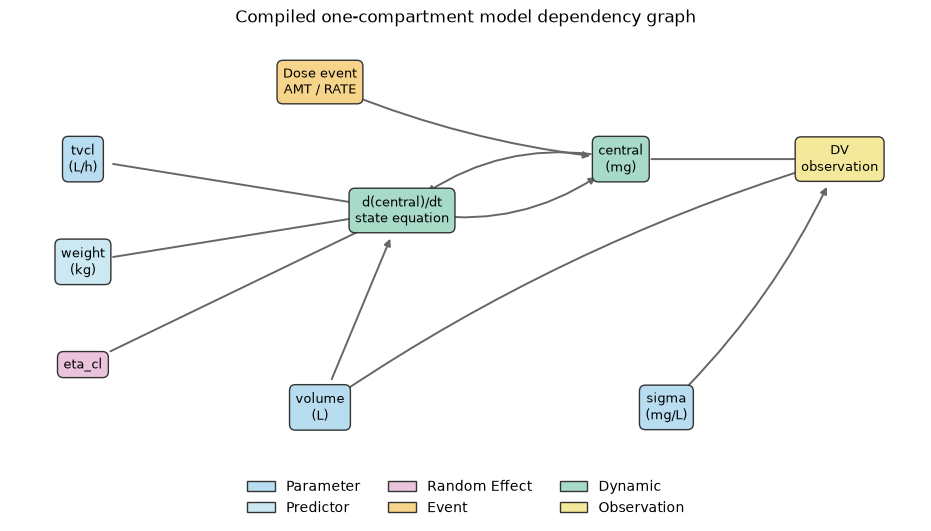

In [6]:
state_equation = model_ir.state_equations[0]
event_mapping = model_ir.events[0]
likelihood_node = model_ir.likelihoods[0]
output_node = model_ir.outputs[0]
eta_name = model_ir.random_effects[0].terms[0]
predictor_name = model_ir.predictors[0].name
state_name = state_equation.state
ode_name = f"d({state_name})/dt"
response_name = likelihood_node.response
dose_name = "dose event"

node_positions = {
    "tvcl": (0.08, 0.70),
    predictor_name: (0.08, 0.46),
    eta_name: (0.08, 0.22),
    "volume": (0.34, 0.12),
    "sigma": (0.72, 0.12),
    dose_name: (0.34, 0.88),
    ode_name: (0.43, 0.58),
    state_name: (0.67, 0.70),
    response_name: (0.91, 0.70),
}
node_labels = {node.name: f"{node.name}\n({node.unit})" for node in model_ir.parameters}
node_labels.update(
    {
        predictor_name: f"{predictor_name}\n({model_ir.predictors[0].unit})",
        eta_name: eta_name,
        dose_name: "Dose event\nAMT / RATE",
        ode_name: f"{ode_name}\nstate equation",
        state_name: f"{state_name}\n({state_equation.unit})",
        response_name: f"{response_name}\nobservation",
    }
)
node_categories = {
    "tvcl": "parameter",
    "volume": "parameter",
    "sigma": "parameter",
    predictor_name: "predictor",
    eta_name: "random effect",
    dose_name: "event",
    ode_name: "dynamic",
    state_name: "dynamic",
    response_name: "observation",
}
dependency_edges = [
    (dose_name, state_name, 0.08),
    ("tvcl", ode_name, 0.00),
    (predictor_name, ode_name, 0.00),
    (eta_name, ode_name, 0.00),
    ("volume", ode_name, 0.00),
    (state_name, ode_name, 0.24),
    (ode_name, state_name, 0.24),
    (state_name, response_name, 0.00),
    ("volume", response_name, -0.08),
    ("sigma", response_name, 0.10),
]

fig, ax = plt.subplots(figsize=(9.2, 5.2), constrained_layout=True)
for source, target, curvature in dependency_edges:
    ax.annotate(
        "",
        xy=node_positions[target],
        xytext=node_positions[source],
        arrowprops={
            "arrowstyle": "-|>",
            "color": PLOT_COLORS["gray"],
            "linewidth": 1.4,
            "shrinkA": 22,
            "shrinkB": 22,
            "connectionstyle": f"arc3,rad={curvature}",
        },
    )
for name, (x_position, y_position) in node_positions.items():
    category = node_categories[name]
    ax.text(
        x_position,
        y_position,
        node_labels[name],
        ha="center",
        va="center",
        fontsize=9.5,
        bbox={
            "boxstyle": "round,pad=0.45",
            "facecolor": NODE_COLORS[category],
            "edgecolor": "#333333",
            "linewidth": 1.0,
        },
    )
legend_categories = [
    "parameter",
    "predictor",
    "random effect",
    "event",
    "dynamic",
    "observation",
]
ax.legend(
    handles=[
        Patch(facecolor=NODE_COLORS[category], edgecolor="#333333", label=category.title())
        for category in legend_categories
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=False,
)
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_title("Compiled one-compartment model dependency graph")
ax.axis("off")
plt.show()

The graph makes the declared pathways explicit: dose fields update the central state, clearance determinants feed its differential equation, and central amount, volume, and residual scale feed the observation. The feedback arrows represent numerical integration of a state-dependent ODE, not an additional statistical effect.

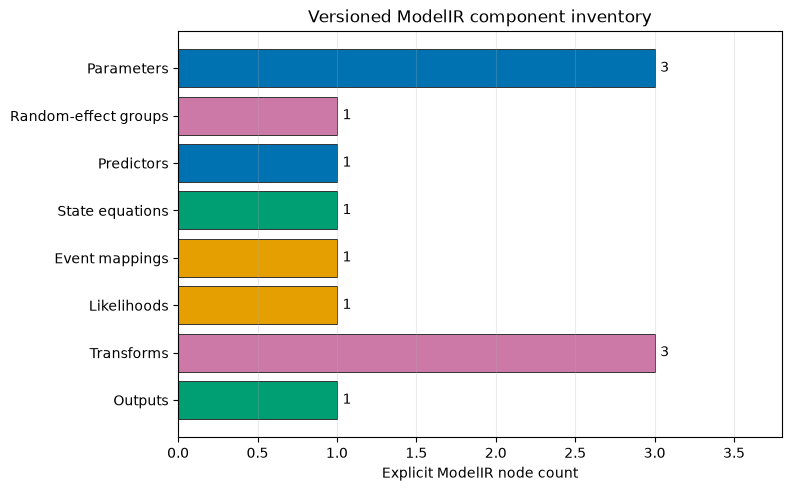

In [7]:
component_inventory = {
    "Parameters": len(model_ir.parameters),
    "Random-effect groups": len(model_ir.random_effects),
    "Predictors": len(model_ir.predictors),
    "State equations": len(model_ir.state_equations),
    "Event mappings": len(model_ir.events),
    "Likelihoods": len(model_ir.likelihoods),
    "Transforms": len(model_ir.transforms),
    "Outputs": len(model_ir.outputs),
}
inventory_labels = list(component_inventory)
inventory_counts = list(component_inventory.values())
inventory_colors = [
    PLOT_COLORS["blue"],
    PLOT_COLORS["purple"],
    PLOT_COLORS["blue"],
    PLOT_COLORS["green"],
    PLOT_COLORS["orange"],
    PLOT_COLORS["orange"],
    PLOT_COLORS["purple"],
    PLOT_COLORS["green"],
]

fig, ax = plt.subplots(figsize=(7.8, 4.8), constrained_layout=True)
bars = ax.barh(
    inventory_labels,
    inventory_counts,
    color=inventory_colors,
    edgecolor="#333333",
    linewidth=0.7,
)
ax.bar_label(bars, padding=4)
ax.invert_yaxis()
ax.set_xlabel("Explicit ModelIR node count")
ax.set_title("Versioned ModelIR component inventory")
ax.set_xlim(0, max(inventory_counts) + 0.8)
ax.grid(axis="x", alpha=0.25)
plt.show()

The three positive parameters each receive an explicit optimizer transform; the dynamic, event, likelihood, and output portions each remain visible as their own typed nodes. Counts describe model structure only—they do not indicate parameter identifiability or estimator readiness.

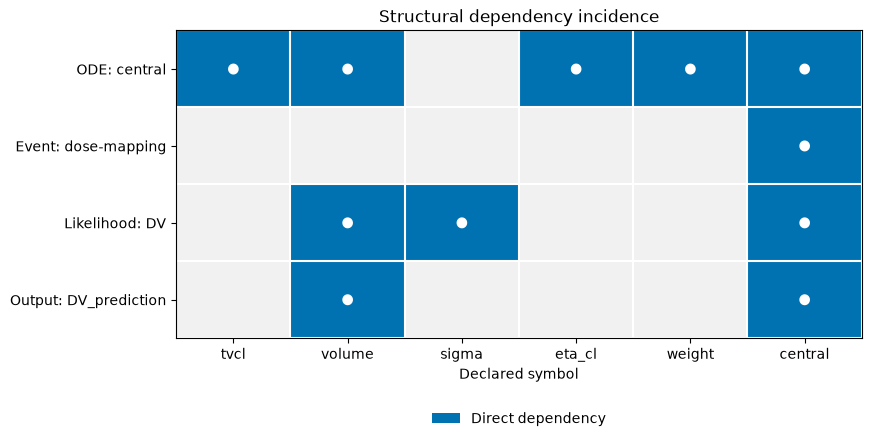

In [8]:
dependency_symbols = (
    [node.name for node in model_ir.parameters]
    + [term for group in model_ir.random_effects for term in group.terms]
    + [node.name for node in model_ir.predictors]
    + [state_name]
)
dependency_rows = [
    (f"ODE: {state_name}", set(state_equation.dependencies)),
    (f"Event: {event_mapping.event_type}", set(event_mapping.dependencies)),
    (f"Likelihood: {response_name}", set(likelihood_node.dependencies)),
    (f"Output: {output_node.name}", set(output_node.dependencies)),
]
dependency_matrix = [
    [int(symbol in dependencies) for symbol in dependency_symbols]
    for _, dependencies in dependency_rows
]

fig, ax = plt.subplots(figsize=(8.6, 4.3), constrained_layout=True)
ax.imshow(
    dependency_matrix,
    aspect="auto",
    cmap=ListedColormap(["#F1F1F1", PLOT_COLORS["blue"]]),
    vmin=0,
    vmax=1,
)
ax.set_xticks(range(len(dependency_symbols)), labels=dependency_symbols)
ax.set_yticks(
    range(len(dependency_rows)),
    labels=[label for label, _ in dependency_rows],
)
ax.set_xticks([index - 0.5 for index in range(len(dependency_symbols) + 1)], minor=True)
ax.set_yticks([index - 0.5 for index in range(len(dependency_rows) + 1)], minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)
for row_index, row in enumerate(dependency_matrix):
    for column_index, present in enumerate(row):
        if present:
            ax.text(column_index, row_index, "●", ha="center", va="center", color="white")
ax.set_xlabel("Declared symbol")
ax.set_title("Structural dependency incidence")
ax.legend(
    handles=[Patch(facecolor=PLOT_COLORS["blue"], label="Direct dependency")],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    frameon=False,
)
plt.show()

The incidence matrix distinguishes direct from propagated relationships. For example, `tvcl`, `weight`, and `eta_cl` directly affect the ODE, while the likelihood depends on them only through the central state; `sigma` enters the likelihood directly.

In [9]:
print("First parameter node:")
print(model_ir.parameters[0].to_dict())
print("\nDose-mapping node:")
print(model_ir.events[0].to_dict())
print("\nState-equation node:")
print(model_ir.state_equations[0].to_dict())

First parameter node:
{'node_type': 'parameter', 'dimensions': [], 'support': 'positive', 'transform': 'log', 'unit': 'L/h', 'differentiability': 'differentiable', 'dependencies': [], 'source_location': None, 'annotations': {'constraint': 'positive', 'description': None}, 'name': 'tvcl', 'initial': 5.0, 'bounds': [0.0, None], 'fixed': False, 'role': 'population-parameter'}

Dose-mapping node:
{'node_type': 'event', 'dimensions': [], 'support': 'real', 'transform': 'identity', 'unit': None, 'differentiability': 'differentiable', 'dependencies': ['central'], 'source_location': None, 'annotations': {}, 'event_type': 'dose-mapping', 'target': 'central', 'fields': {'amount': 'AMT', 'rate': 'RATE', 'duration': 'DUR', 'compartment': 'CMT', 'lag': None, 'bioavailability': None, 'route': 'iv'}}

State-equation node:
{'node_type': 'state_equation', 'dimensions': [], 'support': 'real', 'transform': 'identity', 'unit': 'mg', 'differentiability': 'differentiable', 'dependencies': ['central', 'eta_c

## Semantic JSON round-trip

Canonical JSON is deterministic. Equality and the semantic hash compare the complete versioned IR meaning, not Python object identity.

In [10]:
serialized = model_ir.to_json(indent=2)
reloaded = ModelIR.from_json(serialized)
assert reloaded == model_ir
assert reloaded.semantic_hash == model_ir.semantic_hash

{
    "semantic_hash": model_ir.semantic_hash,
    "round_trip_equal": reloaded == model_ir,
    "hash_preserved": reloaded.semantic_hash == model_ir.semantic_hash,
    "json_characters": len(serialized),
}

{'semantic_hash': '41c72acbf7b36c34accdb741f0470fef03e290e58bd8ce74523d6d6d4edf01a7',
 'round_trip_equal': True,
 'hash_preserved': True,
 'json_characters': 10367}

## Scope note

The typed declaration and ModelIR provide an auditable model contract, not a fitted population analysis. For transparency, current implementation limitations include no production FOCEI or SAEM estimator, no automatic unit conversion, and conservative refusal of opaque constructs; external qualification remains the next step for regulated use.

## Exercises

1. Add a proportional component to the observation error and inspect the likelihood node.
2. Add a second random effect on volume and compare independent versus correlated blocks.
3. Change the weight exponent and confirm that the semantic hash changes.
4. Serialize the IR twice and verify that the canonical JSON strings are identical.